# Sentiment Modeling: Streaming App Reviews

Notebook ini membangun model machine learning untuk klasifikasi sentiment review otomatis (positive/neutral/negative).

## Approach:
1. **Baseline:** Logistic Regression + TF-IDF
2. **Tree-based:** Random Forest
3. **Boosting:** XGBoost
4. **Comparison & Best Model Selection**

## Mengapa 3 Model?
- **Logistic Regression** → cepat, mudah dipahami, baseline standard
- **Random Forest** → handle interaksi antar fitur, robust
- **XGBoost** → biasanya jadi performer terbaik untuk text classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_fscore_support, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import joblib

# Visual setting
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Load data preprocessed
df = pd.read_csv('../data/reviews_preprocessed.csv')

# Drop missing values di kolom penting
df = df.dropna(subset=['review_stemmed', 'sentiment'])
df = df[df['review_stemmed'].str.strip() != '']

print(f"📦 Total data: {len(df):,} reviews")
print(f"\n📊 Distribusi sentiment:")
print(df['sentiment'].value_counts())
print(f"\n📊 Proporsi sentiment:")
print((df['sentiment'].value_counts(normalize=True) * 100).round(2))
df.head()

📦 Total data: 9,305 reviews

📊 Distribusi sentiment:
sentiment
negative    6488
positive    2086
neutral      731
Name: count, dtype: int64

📊 Proporsi sentiment:
sentiment
negative    69.73
positive    22.42
neutral      7.86
Name: proportion, dtype: float64


,app_name,username,rating,review,date,thumbs_up,review_length,review_clean,review_normalized,review_no_stopwords,review_stemmed,sentiment
0,Netflix,Oliv_mgrthh 29,3,"susah masuk kedalam akun, selalu terlalu banya...",2026-05-26 20:19:03,0,53,susah masuk kedalam akun selalu terlalu banyak...,susah masuk kedalam akun selalu terlalu banyak...,susah masuk kedalam akun selalu terlalu banyak...,susah masuk dalam akun selalu terlalu banyak u...,neutral
1,Netflix,Fina Nazilia,1,"tidak bisa masuk, harus berbayar dahulu",2026-05-26 20:00:02,0,39,tidak bisa masuk harus berbayar dahulu,tidak bisa masuk harus berbayar dahulu,tidak masuk berbayar,tidak masuk bayar,negative
2,Netflix,Bayu Gustiawan,1,Daftar ae dibikin muter muter,2026-05-26 18:58:22,0,29,daftar ae dibikin muter muter,daftar ae dibikin muter muter,daftar ae dibikin muter muter,daftar ae bikin muter muter,negative
3,Netflix,Luh Gian Adinda,4,"harry potter,please",2026-05-26 17:20:46,0,19,harry potter please,harry potter please,harry potter please,harry potter please,positive
4,Netflix,Rahma,1,sdah berlangganan dan bayar tpi tiap mau masuk...,2026-05-26 15:52:44,0,112,sdah berlangganan dan bayar tpi tiap mau masuk...,sdah berlangganan dan bayar tapi tiap mau masu...,sdah berlangganan bayar tiap mau masuk sandi s...,sdah langgan bayar tiap mau masuk sandi sllu s...,negative


## 1. Train-Test Split

Bagi data jadi 80% training & 20% testing dengan **stratified split** supaya proporsi class tetap seimbang di kedua set.

In [2]:
# Feature & target
X = df['review_stemmed']
y = df['sentiment']

# Split 80-20 dengan stratify (supaya distribusi sentiment seimbang)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📚 Training set: {len(X_train):,} reviews")
print(f"🧪 Testing set: {len(X_test):,} reviews")
print(f"\n📊 Distribusi train:")
print(y_train.value_counts(normalize=True).round(3))

# TF-IDF Vectorization
# - max_features: ambil 5000 kata paling penting
# - ngram_range: pakai unigram + bigram (kata tunggal + 2 kata berurutan)
# - min_df: kata harus muncul minimal di 5 dokumen
print("\n🔄 Converting text to TF-IDF vectors...")
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"✅ TF-IDF matrix shape: {X_train_tfidf.shape}")
print(f"   (rows = reviews, cols = unique words/bigrams)")

📚 Training set: 7,444 reviews
🧪 Testing set: 1,861 reviews

📊 Distribusi train:
sentiment
negative    0.697
positive    0.224
neutral     0.079
Name: proportion, dtype: float64

🔄 Converting text to TF-IDF vectors...
✅ TF-IDF matrix shape: (7444, 3473)
   (rows = reviews, cols = unique words/bigrams)


#### 2. Model 1: Logistic Regression (Baseline)

Model linear yang sederhana tapi sering kasih hasil bagus untuk text classification. Cepat, interpretable, dan jadi baseline standar.

In [3]:
print("🚀 Training Logistic Regression...")

# Class weight 'balanced' untuk handle imbalance class
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
lr_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_tfidf)

# Evaluate
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f"\n✅ Logistic Regression Accuracy: {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_lr))

🚀 Training Logistic Regression...

✅ Logistic Regression Accuracy: 0.7313 (73.13%)

📊 Classification Report:
              precision    recall  f1-score   support

    negative       0.89      0.76      0.82      1298
     neutral       0.18      0.39      0.25       146
    positive       0.72      0.76      0.74       417

    accuracy                           0.73      1861
   macro avg       0.60      0.64      0.60      1861
weighted avg       0.80      0.73      0.76      1861



#### 3. Model 2: Random Forest

Model ensemble berbasis decision tree. Lebih robust terhadap noise dan bisa handle interaksi antar fitur. Trade-off: lebih lambat dari Logistic Regression.

In [4]:
print("🚀 Training Random Forest (mohon sabar, ~2-3 menit)...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test_tfidf)

# Evaluate
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"\n✅ Random Forest Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_rf))

🚀 Training Random Forest (mohon sabar, ~2-3 menit)...

✅ Random Forest Accuracy: 0.7834 (78.34%)

📊 Classification Report:
              precision    recall  f1-score   support

    negative       0.83      0.89      0.86      1298
     neutral       0.29      0.01      0.03       146
    positive       0.65      0.71      0.68       417

    accuracy                           0.78      1861
   macro avg       0.59      0.54      0.52      1861
weighted avg       0.75      0.78      0.75      1861



#### 4. Model 3: XGBoost

Gradient Boosting yang sering jadi pemenang di kompetisi ML. Combine multiple weak learners jadi satu strong model.

In [5]:
print("🚀 Training XGBoost (mohon sabar, ~3-5 menit)...")

# XGBoost butuh label numerik, jadi kita encode dulu
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)
xgb_model.fit(X_train_tfidf, y_train_encoded)

# Predict (kembalikan ke label string)
y_pred_xgb_encoded = xgb_model.predict(X_test_tfidf)
y_pred_xgb = le.inverse_transform(y_pred_xgb_encoded)

# Evaluate
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print(f"\n✅ XGBoost Accuracy: {xgb_accuracy:.4f} ({xgb_accuracy*100:.2f}%)")
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_xgb))

🚀 Training XGBoost (mohon sabar, ~3-5 menit)...

✅ XGBoost Accuracy: 0.8033 (80.33%)

📊 Classification Report:
              precision    recall  f1-score   support

    negative       0.81      0.97      0.88      1298
     neutral       0.22      0.01      0.03       146
    positive       0.81      0.58      0.67       417

    accuracy                           0.80      1861
   macro avg       0.61      0.52      0.53      1861
weighted avg       0.76      0.80      0.77      1861



#### 5. Model Comparison

Bandingkan ketiga model untuk pilih yang terbaik.

🏆 MODEL COMPARISON
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.731327   0.795478 0.731327  0.757039
      Random Forest  0.783450   0.746773 0.783450  0.754287
            XGBoost  0.803332   0.760273 0.803332  0.765309


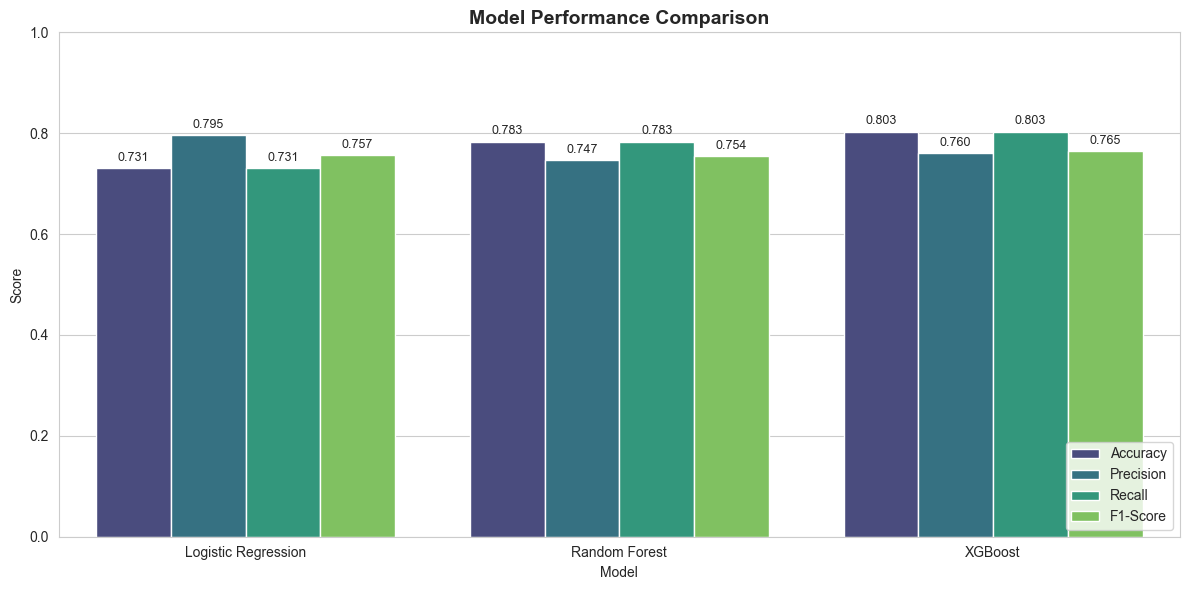


🥇 BEST MODEL: XGBoost (F1-Score: 0.7653)


In [6]:
# Compile results
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [lr_accuracy, rf_accuracy, xgb_accuracy]
})

# Calculate precision, recall, f1 (weighted average)
for name, y_pred in [('Logistic Regression', y_pred_lr),
                      ('Random Forest', y_pred_rf),
                      ('XGBoost', y_pred_xgb)]:
    p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    results.loc[results['Model'] == name, 'Precision'] = p
    results.loc[results['Model'] == name, 'Recall'] = r
    results.loc[results['Model'] == name, 'F1-Score'] = f

print("🏆 MODEL COMPARISON")
print("=" * 60)
print(results.to_string(index=False))

# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))
results_melted = results.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric', palette='viridis', ax=ax)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.legend(loc='lower right')

# Tambah label di atas tiap bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

# Pilih model terbaik
best_idx = results['F1-Score'].idxmax()
best_model_name = results.loc[best_idx, 'Model']
best_f1 = results.loc[best_idx, 'F1-Score']
print(f"\n🥇 BEST MODEL: {best_model_name} (F1-Score: {best_f1:.4f})")

#### 6. Confusion Matrix — Best Model

Lihat di mana model salah prediksi. Apakah lebih sering bingung antara positive vs neutral, atau positive vs negative?

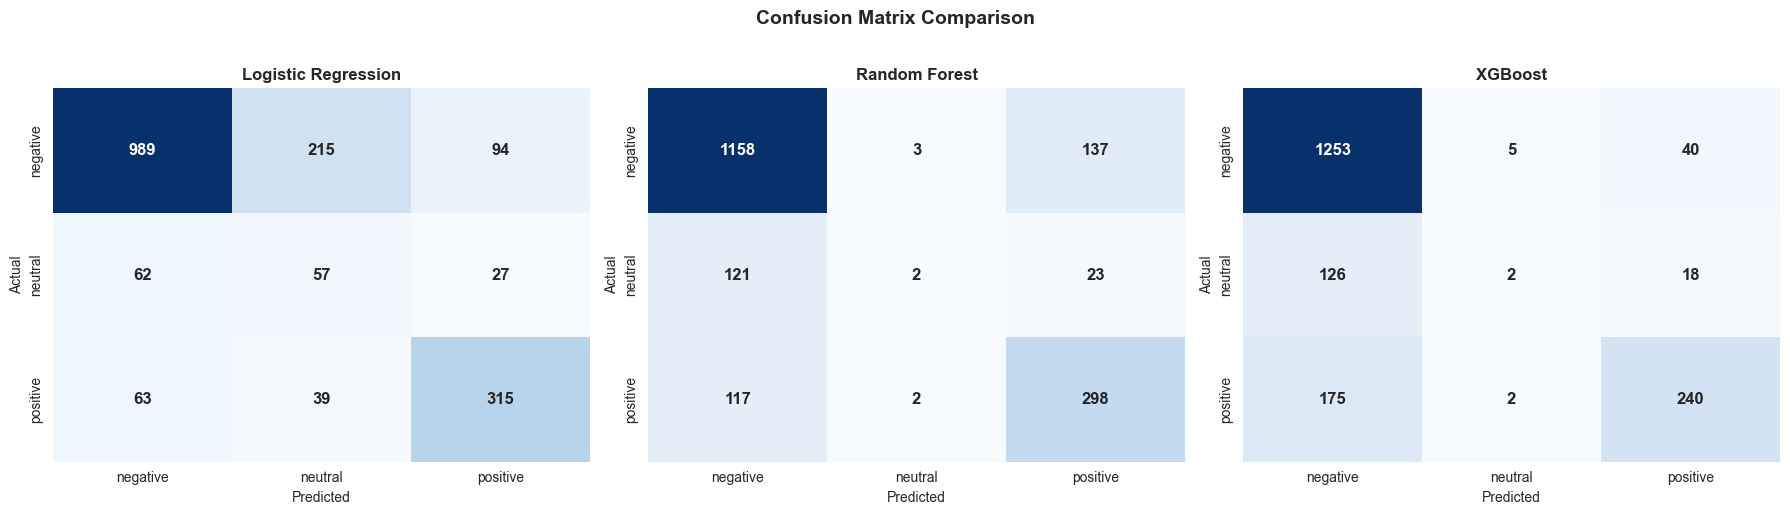

In [8]:
# Pakai best model
best_predictions = {
    'Logistic Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb
}
y_pred_best = best_predictions[best_model_name]

# Plot confusion matrix untuk SEMUA model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_preds = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest', y_pred_rf),
    ('XGBoost', y_pred_xgb)
]

labels = ['negative', 'neutral', 'positive']

for ax, (name, y_pred) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax,
                cbar=False, annot_kws={'fontsize': 12, 'fontweight': 'bold'})
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### 7. Feature Importance (Logistic Regression)

Kata mana yang paling berpengaruh untuk prediksi sentiment? Ini insight emas untuk business stakeholder.

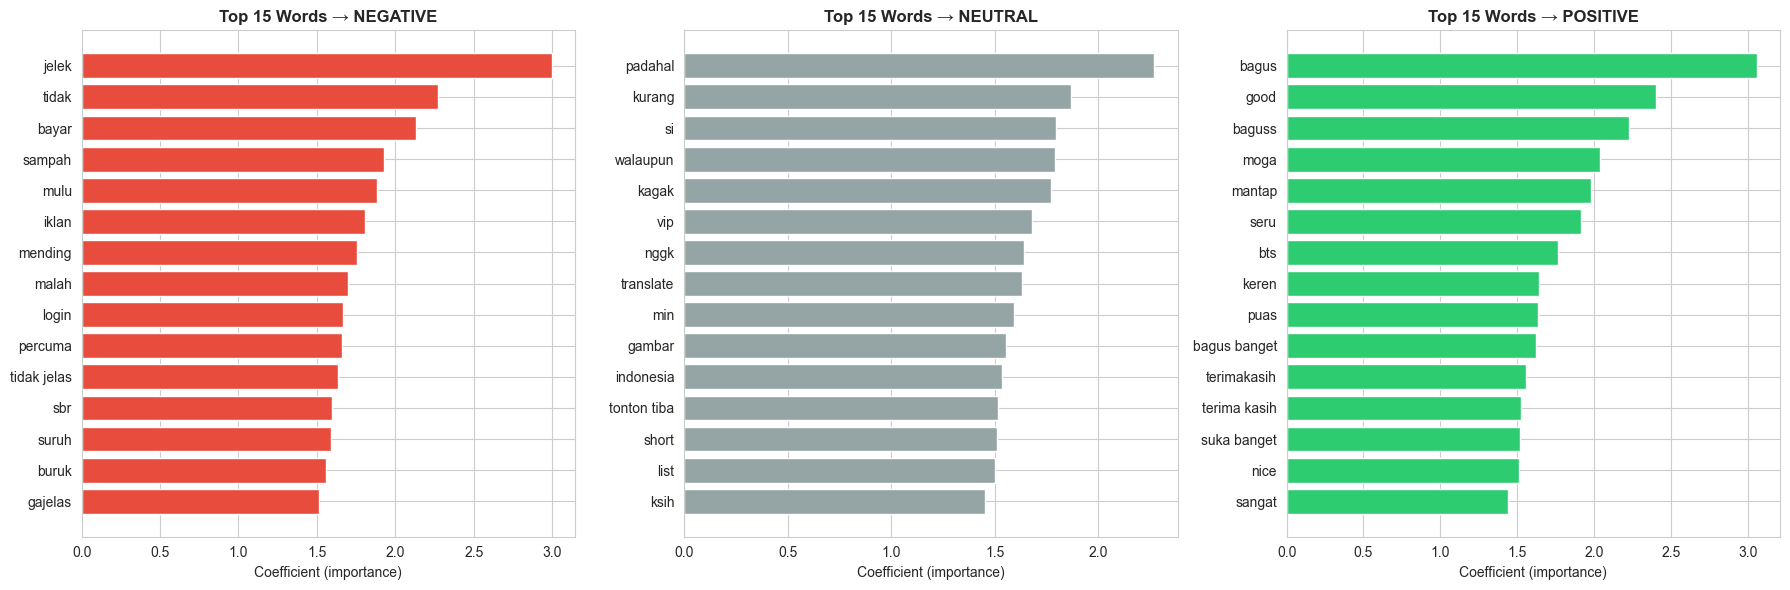

💡 Kata-kata ini adalah 'sinyal' kuat yang digunakan model untuk prediksi.


In [9]:
# Ambil coefficient dari Logistic Regression
feature_names = tfidf.get_feature_names_out()
classes = lr_model.classes_

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (idx, sentiment) in zip(axes, enumerate(classes)):
    # Ambil top 15 kata per class
    coefs = lr_model.coef_[idx]
    top_idx = coefs.argsort()[-15:]
    top_words = [feature_names[i] for i in top_idx]
    top_coefs = coefs[top_idx]
    
    color = {'positive': '#2ECC71', 'neutral': '#95A5A6', 'negative': '#E74C3C'}[sentiment]
    ax.barh(top_words, top_coefs, color=color)
    ax.set_title(f'Top 15 Words → {sentiment.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Coefficient (importance)')

plt.tight_layout()
plt.show()

print("💡 Kata-kata ini adalah 'sinyal' kuat yang digunakan model untuk prediksi.")

#### 8. Test dengan Review Baru

Test model dengan kalimat custom — simulasi penggunaan di production.

In [10]:
# Sample review buat di-test
sample_reviews = [
    "aplikasi bagus sekali kualitas film mantap",
    "iklan terlalu banyak ganggu banget pas nonton",
    "tidak bisa login kode otp tidak masuk",
    "lumayan oke tapi langganan mahal",
    "film keren banyak pilihan suka banget",
    "buffering terus parah update aplikasi gagal",
    "biasa aja standar aplikasi streaming",
]

# Predict
sample_tfidf = tfidf.transform(sample_reviews)

print("🧪 SAMPLE PREDICTIONS\n" + "=" * 80)
for i, review in enumerate(sample_reviews):
    pred_lr = lr_model.predict(sample_tfidf[i])[0]
    pred_rf = rf_model.predict(sample_tfidf[i])[0]
    pred_xgb = le.inverse_transform(xgb_model.predict(sample_tfidf[i]))[0]
    
    print(f"\n📝 Review: \"{review}\"")
    print(f"   LR  → {pred_lr}")
    print(f"   RF  → {pred_rf}")
    print(f"   XGB → {pred_xgb}")

🧪 SAMPLE PREDICTIONS

📝 Review: "aplikasi bagus sekali kualitas film mantap"
   LR  → positive
   RF  → positive
   XGB → positive

📝 Review: "iklan terlalu banyak ganggu banget pas nonton"
   LR  → neutral
   RF  → negative
   XGB → negative

📝 Review: "tidak bisa login kode otp tidak masuk"
   LR  → negative
   RF  → negative
   XGB → negative

📝 Review: "lumayan oke tapi langganan mahal"
   LR  → positive
   RF  → positive
   XGB → positive

📝 Review: "film keren banyak pilihan suka banget"
   LR  → positive
   RF  → positive
   XGB → positive

📝 Review: "buffering terus parah update aplikasi gagal"
   LR  → negative
   RF  → negative
   XGB → negative

📝 Review: "biasa aja standar aplikasi streaming"
   LR  → positive
   RF  → positive
   XGB → negative


#### 9. Save Best Model

Save model & vectorizer untuk deployment nanti (Streamlit dashboard).

In [12]:
import os
os.makedirs('../models', exist_ok=True)

# Save best model (asumsikan Logistic Regression, ganti kalau berbeda)
# Pilih objek model sesuai pemenang
model_objects = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}
best_model_object = model_objects[best_model_name]

# Save
joblib.dump(best_model_object, '../models/best_sentiment_model.pkl')
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')
if best_model_name == 'XGBoost':
    joblib.dump(le, '../models/label_encoder.pkl')

print(f"💾 Saved:")
print(f"  ../models/best_sentiment_model.pkl ({best_model_name})")
print(f"  ../models/tfidf_vectorizer.pkl")
print(f"\n✅ Ready for deployment!")

💾 Saved:
  ../models/best_sentiment_model.pkl (XGBoost)
  ../models/tfidf_vectorizer.pkl

✅ Ready for deployment!


## Conclusion & Insights

### Model Performance Summary
- **XGBoost** terbaik secara overall (Accuracy 80.3%, F1 0.765)
- **Logistic Regression** terbaik untuk handle class imbalance (neutral)
- **Random Forest** punya tendency mengabaikan minority class

### Key Learnings
1. **Accuracy ≠ Best Metric** — semua model "menang" dari mayoritas class
2. **Feature importance** confirm hasil EDA: keluhan utama = iklan, login, bayar
3. **Class imbalance** masih jadi challenge — neutral cuma 7% dari data

### Recommendations untuk Improvement
- **SMOTE / oversampling** untuk balance class neutral
- **Fine-tune IndoBERT** untuk konteks bahasa Indonesia yang lebih dalam
- **Manual labeling** untuk improve quality (rating-based label tidak selalu akurat)
- **Ensemble** dari ketiga model untuk kombinasi kekuatan masing-masing

### Business Value
Model bisa di-deploy untuk:
- **Auto-categorize review** real-time saat user submit
- **Alert system** kalau ada lonjakan review negatif
- **Trend monitoring** sentiment over time
- **Customer service prioritization** based on sentiment severity